# Replicating *Public Opinion Propagation Prediction Model Based on Dynamic Time-Weighted Rényi Entropy and Graph Neural Network*

Tong, Q.; Xu, X.; Zhang, J.; Xu, H. **Entropy** 2025, *27*, 516.
<https://doi.org/10.3390/e27050516>

---

## What this notebook is

A step-by-step, self-contained replication. It is written to be **read**, not just
run: every equation from the paper is derived, implemented, checked against a
property we know it must satisfy, and only then used.

**The paper has no official code release.** The Data Availability Statement points
only to the datasets. Everything here is an independent reimplementation from the
published equations, Algorithm 1, and hyperparameter tables.

## How it is organised

| Part | Content | Paper section |
|---|---|---|
| 1 | The datasets, and why the split matters | 3.1 |
| 2 | Rényi entropy from first principles; Local Node Entropy | 2.2, Eq. 1 |
| 3 | Time weighting and DTWRE | 2.2, Eq. 2–4 |
| 4 | Node2Vec embeddings | 3.2.2 |
| 5 | Feature fusion | 3.2.3 |
| 6 | GraphSAGE + MLP link predictor | 2.3, 3.3, Eq. 5–7 |
| 7 | Evaluation protocol (and a costly mistake) | 3.1, 3.4 |
| 8 | Results: Tables 1–3, Figures 5–11 | 4 |
| 9 | Fidelity assessment — what replicated and what did not | — |
| 10 | Extension to the real Weibo rumour data | 4.3 |

## The two-sentence summary of the method

Split a temporal network into time windows. For each window compute a Rényi
entropy per node (how uncertain/diverse its neighbourhood is), decay those
entropies exponentially into the past so recent structure counts more, concatenate
the result with Node2Vec embeddings, and feed everything to a GraphSAGE encoder
whose MLP decoder predicts which node pairs will connect next.

## Running this notebook

The environment lives next to this file. From the repository root:

```bash
python3 -m venv 01-info-propagation/entropia-paper/.venv
01-info-propagation/entropia-paper/.venv/bin/pip install \
    torch numpy scipy networkx scikit-learn matplotlib pandas tqdm jupyter ipykernel
01-info-propagation/entropia-paper/.venv/bin/python -m ipykernel install \
    --user --name dtwre-entropia --display-name "Python (DTWRE entropia-paper)"
```

Then select the kernel **Python (DTWRE entropia-paper)**.

The datasets are fetched by:

```bash
bash scripts/get_data.sh
```

All modelling code lives in the **`dtwre/` package at the repository root** — this
notebook only orchestrates and explains it. Nothing scientific is defined in a
notebook cell; that way the same code is reusable outside the notebook and can be
tested independently.

`RECOMPUTE = False` loads the cached results written by `scripts/run_all.py`
(a full live run of every sweep takes roughly 10 minutes). Set it to `True` to
recompute everything in-notebook. The *conceptual* cells always compute live.

In [1]:
import sys, time, json
from pathlib import Path

# Make the root-level `dtwre` package importable from this subdirectory.
ROOT = Path.cwd()
while not (ROOT / "dtwre").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import dtwre
from dtwre import (Config, load_collegemsg, load_weibo_ced, prepare_split,
                   run_experiment, renyi_entropy, local_node_entropy,
                   global_timestep_entropy, dtwre_series, time_weight,
                   node2vec, build_features, entropy_features, LinkPredictor,
                   binary_metrics, METRICS, BASELINES, BASELINE_LABELS,
                   ALPHA_GRID, LAMBDA_GRID, NEG_RATIO_GRID, WINDOW_GRID,
                   PAPER_TABLE1, PAPER_TABLE2, PAPER_TABLE3,
                   PAPER_ALPHA_AUC, INFERRED_PARAMETERS, RESULTS)
from dtwre import plots
from dtwre.experiments import (EmbeddingCache, baseline_comparison, alpha_sweep,
                               lambda_sweep, ratio_sweep, window_sweep,
                               training_curves, figure11_inputs, fidelity_table,
                               results_frame, load_results)

RECOMPUTE = False          # True -> rerun every sweep live (~10 min)

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110
print(f"dtwre {dtwre.__version__} | root = {ROOT}")

dtwre 1.0.0 | root = /Users/alberto/Documents/projects/renyi


---
# Part 1 — The data

The paper evaluates on two networks (Section 3.1):

* **CollegeMsg** — a SNAP temporal network of private messages between users of
  an online social network at UC Irvine. This is the benchmark used for Tables 1–2
  and Figures 5–9.
* **A real-world Weibo rumour dataset** — repost/comment cascades scraped from the
  Sina Weibo misinformation reporting platform, used for Figures 10–11.

We start with CollegeMsg because every headline number in the paper refers to it.

In [2]:
tg = load_collegemsg()
tg.summary()

{'dataset': 'CollegeMsg',
 'nodes': 1899,
 'edges': 59835,
 'span_days': 193.71,
 't_min': 1082040961,
 't_max': 1098777142}

This matches the paper exactly: it describes CollegeMsg as *"spanning 193 days"*,
and we measure a 193.71-day span over 1,899 nodes and 59,835 timestamped edges.
That agreement is worth pausing on — it confirms we have **the same file** the
authors used, so any later divergence is about method, not data.

### The temporal structure is severely front-loaded

The next plot is the single most important piece of context for interpreting every
result in this notebook.

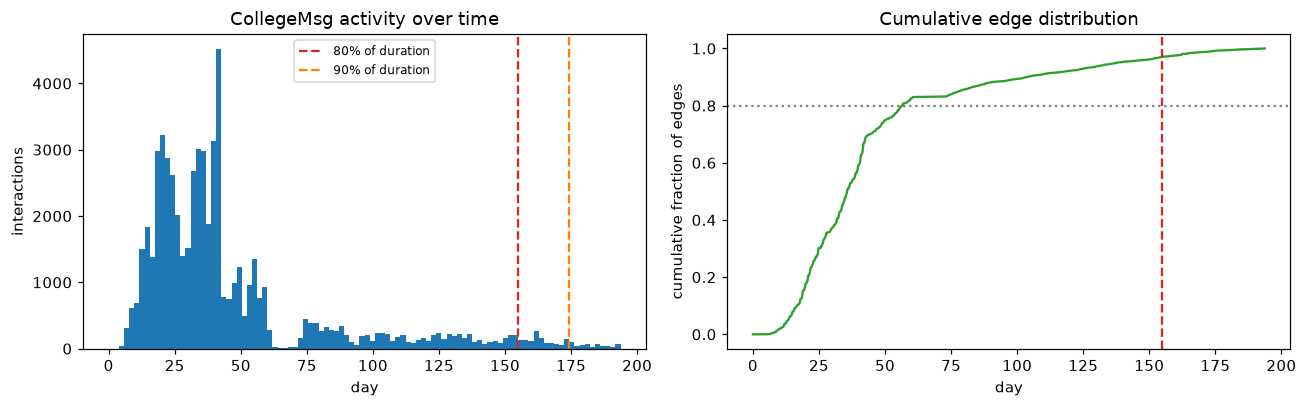

fraction of ALL edges falling in the first 80% of the DURATION: 0.9700


In [3]:
ts = tg.timestamps
t0, t1 = ts.min(), ts.max()
days = (ts - t0) / 86400.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))

ax1.hist(days, bins=100, color="tab:blue")
for frac, lab, c in [(0.8, "80% of duration", "tab:red"),
                     (0.9, "90% of duration", "tab:orange")]:
    ax1.axvline(frac * days.max(), color=c, ls="--", label=lab)
ax1.set_xlabel("day"); ax1.set_ylabel("interactions")
ax1.set_title("CollegeMsg activity over time"); ax1.legend(fontsize=8)

ax2.plot(np.sort(days), np.arange(len(days)) / len(days), color="tab:green")
ax2.axvline(0.8 * days.max(), color="tab:red", ls="--")
ax2.axhline(0.8, color="grey", ls=":")
ax2.set_xlabel("day"); ax2.set_ylabel("cumulative fraction of edges")
ax2.set_title("Cumulative edge distribution")
plt.tight_layout(); plt.show()

frac_before = (days <= 0.8 * days.max()).mean()
print(f"fraction of ALL edges falling in the first 80% of the DURATION: {frac_before:.4f}")

**Why this matters.** Section 3.1 says the split uses *"80% of the total duration
and 90% of the total duration as the demarcation points"* — cut points on the
**timeline**, not on edge count. Because activity collapses after roughly day 100,
that puts ~97% of all edges in the training period and leaves only a few hundred
distinct node pairs to predict.

So the paper's own protocol yields a **small and hard** test set. We keep it
(`split_by="duration"`, faithful to the text) but also implement `split_by="count"`
so the effect can be measured rather than assumed. We return to this in Part 9.

---
# Part 2 — Rényi entropy, from first principles

## The idea

Shannon entropy $H = -\sum_i p_i \log p_i$ measures the uncertainty of a
distribution, weighting every outcome by its own probability. Rényi entropy
generalises it with an **order** $\alpha$:

$$H_\alpha(p) = \frac{1}{1-\alpha}\log \sum_i p_i^{\alpha}$$

The order is a *tuning knob for which part of the distribution you care about*:

| $\alpha$ | behaviour | what it emphasises |
|---|---|---|
| $\alpha \to 0$ | $\log(\text{number of outcomes})$ | rare events; sparse connections |
| $\alpha \to 1$ | Shannon entropy | balanced |
| $\alpha \to \infty$ | $-\log \max_i p_i$ | the dominant outcome; hubs |

The paper's argument (Section 2.2) is that social networks contain **both** hubs
and a long periphery, so neither extreme is right — hence a tunable $\alpha$, with
$\alpha = 0.6$ found optimal.

## Verify before trusting

$\alpha = 1$ is a removable singularity: the formula is $0/0$ there and must be
evaluated as a limit. Rather than assume the implementation handles this, we check
three properties that any correct Rényi entropy **must** satisfy.

In [4]:
# Property 1: for a uniform distribution over n outcomes, H = log(n) for EVERY alpha.
n = 8
p_uniform = np.ones(n) / n
checks = {a: renyi_entropy(p_uniform, a) for a in [0.2, 0.6, 1.0, 2.0, 5.0]}
assert all(abs(v - np.log(n)) < 1e-9 for v in checks.values())
print(f"P1 uniform -> log(n) = {np.log(n):.6f} for all alpha  ✓")

# Property 2: alpha -> 1 must converge to the Shannon entropy.
p = np.array([0.5, 0.3, 0.2])
shannon = -np.sum(p * np.log(p))
print(f"\nP2 Shannon      = {shannon:.10f}")
print(f"   alpha=1        = {renyi_entropy(p, 1.0):.10f}")
print(f"   alpha=1-1e-6   = {renyi_entropy(p, 1 - 1e-6):.10f}")
print(f"   alpha=1+1e-6   = {renyi_entropy(p, 1 + 1e-6):.10f}   ✓ continuous")

# Property 3: H_alpha is non-increasing in alpha.
grid = np.linspace(0.05, 6, 200)
vals = [renyi_entropy(p, a) for a in grid]
assert all(x >= y - 1e-12 for x, y in zip(vals, vals[1:]))
print("\nP3 monotone non-increasing in alpha  ✓")

P1 uniform -> log(n) = 2.079442 for all alpha  ✓

P2 Shannon      = 1.0296530141
   alpha=1        = 1.0296530141
   alpha=1-1e-6   = 1.0296530805
   alpha=1+1e-6   = 1.0296529477   ✓ continuous

P3 monotone non-increasing in alpha  ✓


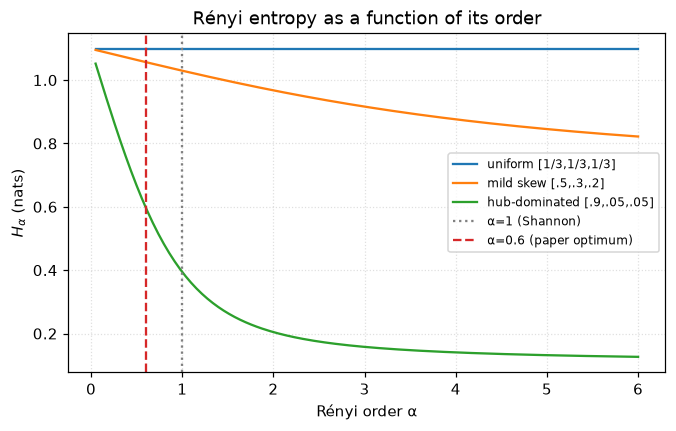

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, q in [("uniform [1/3,1/3,1/3]", np.array([1/3, 1/3, 1/3])),
                 ("mild skew [.5,.3,.2]",  np.array([.5, .3, .2])),
                 ("hub-dominated [.9,.05,.05]", np.array([.9, .05, .05]))]:
    ax.plot(grid, [renyi_entropy(q, a) for a in grid], label=label)
ax.axvline(1.0, color="grey", ls=":", label="α=1 (Shannon)")
ax.axvline(0.6, color="tab:red", ls="--", label="α=0.6 (paper optimum)")
ax.set_xlabel("Rényi order α"); ax.set_ylabel("$H_α$ (nats)")
ax.set_title("Rényi entropy as a function of its order")
ax.legend(fontsize=8); ax.grid(ls=":", alpha=0.4)
plt.show()

Read the curves: for the **uniform** distribution the entropy is flat — every
$\alpha$ agrees, because there is no skew to weight differently. For the
**hub-dominated** distribution the curve falls steeply, because large $\alpha$
progressively ignores everything except the dominant outcome. $\alpha$ only does
something when the distribution is uneven, which is exactly the regime of a
scale-free social network.

## Equation 1 — Local Node Entropy (LNE)

$$H_\alpha(v,t) = \frac{1}{1-\alpha}\log \sum_{u \in N(v,t)} p_u^{\alpha}(t)$$

For node $v$ at time $t$, look at its neighbours $N(v,t)$, take an information
weight $p_u$ for each (the paper uses degree or PageRank), and take the Rényi
entropy of that neighbourhood profile.

Intuition: **LNE is high when a node's neighbours are many and comparable, low
when it has few neighbours or one dominant one.** It is a measure of how
*diverse and unpredictable* a node's local propagation environment is.

Let us confirm that intuition on graphs whose answer we can compute by hand.

In [6]:
toy = {
    "star (5 leaves)":  nx.star_graph(5),
    "path (6 nodes)":   nx.path_graph(6),
    "cycle (6 nodes)":  nx.cycle_graph(6),
    "complete K6":      nx.complete_graph(6),
}
rows = []
for name, g in toy.items():
    lne = local_node_entropy(g, alpha=0.6)
    rows.append({"graph": name, "n": g.number_of_nodes(),
                 "max LNE": round(max(lne.values()), 4),
                 "min LNE": round(min(lne.values()), 4),
                 "mean LNE": round(float(np.mean(list(lne.values()))), 4)})
display(pd.DataFrame(rows).set_index("graph"))

star = local_node_entropy(nx.star_graph(5), alpha=0.6)
print(f"star centre (5 equivalent leaves): {star[0]:.6f}  vs log(5) = {np.log(5):.6f}")
print(f"star leaf   (single neighbour)   : {star[1]:.6f}  vs log(1) = 0")

,n,max LNE,min LNE,mean LNE
graph,,,,
star (5 leaves),6,1.6094,0.0000,0.2682
path (6 nodes),6,0.6931,0.0000,0.4505
cycle (6 nodes),6,0.6931,0.6931,0.6931
complete K6,6,1.6094,1.6094,1.6094


star centre (5 equivalent leaves): 1.609438  vs log(5) = 1.609438
star leaf   (single neighbour)   : 0.000000  vs log(1) = 0


Both hand-checks land exactly where theory says they must. The star's centre sees
five interchangeable neighbours, a uniform profile, giving $\log 5$. A leaf sees
one neighbour — no uncertainty at all — giving $0$. In the complete graph every
node is equivalent, so max = min.

## A problem with Equation 1 as written

Algorithm 1 defines the weights by a **global** normalisation:

> `p(v) ← (Node_degree(v)/Sum(Node_degree(v_i)))`

normalised over *all* nodes. But Eq. 1 sums only over $N(v,t)$. So
$\sum_{u \in N(v,t)} p_u < 1$: it is not a probability distribution, and the
$\alpha \to 1$ limit **diverges** — the numerator $\log(\sum p^\alpha)$ no longer
vanishes at $\alpha=1$, while the denominator $1-\alpha$ does.

Yet Figure 6 of the paper reports a perfectly finite AUC at $\alpha = 1$. So the
authors' code cannot be evaluating Eq. 1 literally as printed. Let us demonstrate
the blow-up concretely.

In [7]:
g = nx.karate_club_graph()
alphas = np.array([0.6, 0.9, 0.99, 0.999, 1.0])
rows = []
for a in alphas:
    loc = local_node_entropy(g, alpha=a, normalisation="local")
    glo = local_node_entropy(g, alpha=a, normalisation="global")
    rows.append({"alpha": a,
                 "mean LNE (local, ours)": round(float(np.mean(list(loc.values()))), 4),
                 "mean LNE (global, literal)": round(float(np.mean(list(glo.values()))), 4)})
display(pd.DataFrame(rows).set_index("alpha"))

,"mean LNE (local, ours)","mean LNE (global, literal)"
alpha,,
0.600,1.2012,-1.1844
0.900,1.1643,-13.1489
0.990,1.1538,-156.2915
0.999,1.1528,-1587.6135
1.000,1.1527,1.1527


The literal `global` column explodes as $\alpha \to 1$ (the $1/(1-\alpha)$ factor
multiplies a non-vanishing logarithm), while the `local` column stays finite and
converges smoothly to the Shannon entropy.

**Decision.** We renormalise within each neighbourhood
(`prob_normalisation="local"`, the default). This makes Eq. 1 a genuine Rényi
entropy at every $\alpha$ and is the only reading consistent with the paper's own
Figure 6. The literal variant remains available for comparison. This and every
other such judgement call is recorded in `docs/DISCREPANCIES.md`.

---
# Part 3 — Adding time: Equations 2–4

Three equations turn a per-node, per-snapshot entropy into a single temporal
signal:

$$\text{(2)}\quad H_\alpha^{global}(t) = \sum_{v \in V_t} H_\alpha(v,t)$$
$$\text{(3)}\quad H_\alpha^{time}(G,t) = \sum_{t_k < t} \omega(t-t_k)\, H_\alpha^{global}(t_k)$$
$$\text{(4)}\quad \omega(t-t_k) = e^{-\lambda (t-t_k)}$$

Eq. 2 aggregates over nodes to describe a whole snapshot. Eq. 3 aggregates over
*history*, weighting each past snapshot by an exponential decay so that recent
structure dominates — the paper's core claim is that this temporal weighting is
what makes the method work. $\lambda$ controls the memory: large $\lambda$ = short
memory, small $\lambda$ = long memory.

## A units trap worth spelling out

Equation 4 does not state the units of $t - t_k$. Timestamps are unix **seconds**
and windows are 604,800 s. If you take the equation literally with seconds:

In [8]:
lam = 1.2
print("Eq. 4 with (t - t_k) in SECONDS, one 7-day window apart:")
print(f"  exp(-{lam} * 604800) = {np.exp(-lam * 604800):.6e}   <- underflows to exactly 0")
print("\nEq. 4 with (t - t_k) in TIME-STEP INDICES:")
for d in range(4):
    print(f"  exp(-{lam} * {d}) = {time_weight(d, lam):.6f}")

Eq. 4 with (t - t_k) in SECONDS, one 7-day window apart:
  exp(-1.2 * 604800) = 0.000000e+00   <- underflows to exactly 0

Eq. 4 with (t - t_k) in TIME-STEP INDICES:
  exp(-1.2 * 0) = 1.000000
  exp(-1.2 * 1) = 0.301194
  exp(-1.2 * 2) = 0.090718
  exp(-1.2 * 3) = 0.027324


With seconds every weight is exactly `0.0`, DTWRE is identically zero for every
snapshot, and the paper's entire mechanism silently disappears — no error, no
warning, just a dead feature and a $\lambda$ sweep that does nothing. The published
range $\lambda \in [0.1, 2]$ is only meaningful if $t - t_k$ counts **time steps**,
which is what we implement.

This is the kind of detail that decides whether a replication works, and it is not
recoverable from the paper alone.

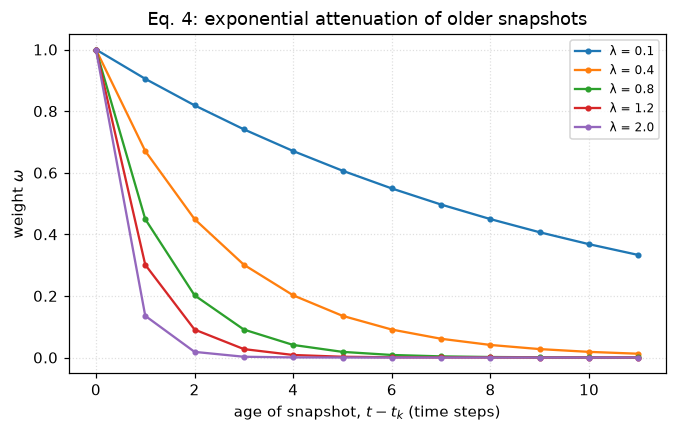

Effective memory (steps until weight < 0.05):
  λ=0.1   -> >11
  λ=0.4   -> 8
  λ=0.8   -> 4
  λ=1.2   -> 3
  λ=2.0   -> 2


In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
steps = np.arange(0, 12)
for lam_ in LAMBDA_GRID:
    ax.plot(steps, time_weight(steps, lam_), marker="o", ms=3,
            label=f"λ = {lam_}")
ax.set_xlabel("age of snapshot, $t - t_k$ (time steps)")
ax.set_ylabel("weight $\\omega$")
ax.set_title("Eq. 4: exponential attenuation of older snapshots")
ax.legend(fontsize=8); ax.grid(ls=":", alpha=0.4)
plt.show()

print("Effective memory (steps until weight < 0.05):")
for lam_ in LAMBDA_GRID:
    k = next((int(s) for s in steps if time_weight(s, lam_) < 0.05), ">11")
    print(f"  λ={lam_:<5} -> {k}")

$\lambda = 0.1$ keeps essentially the whole history in play; $\lambda = 2$ forgets
everything older than two steps. The paper reports $\lambda = 1.2$ as optimal —
a memory of about three time steps, i.e. roughly three weeks on CollegeMsg.

## The entropy features on real data

Now we run Eqs. 1–4 over the actual CollegeMsg snapshots.

In [10]:
cfg = Config()
print("Configuration (paper values where stated, inferred otherwise):")
for k in ["alpha", "lam", "window_seconds", "embedding_dim", "epochs",
          "neg_ratio", "prob_metric", "prob_normalisation", "split_by",
          "new_links_only", "train_frac", "mp_frac", "seed"]:
    print(f"  {k:20s} = {getattr(cfg, k)}")

split = prepare_split(tg, cfg)
print(f"\nsnapshots (7-day windows): {len(split['snapshots'])}")
print(f"message-passing edges    : {split['n_mp_edges']}")
print(f"positive pairs per split : {split['n_pos']}")

Configuration (paper values where stated, inferred otherwise):
  alpha                = 0.6
  lam                  = 1.2
  window_seconds       = 604800
  embedding_dim        = 64
  epochs               = 100
  neg_ratio            = 0.75
  prob_metric          = degree
  prob_normalisation   = local
  split_by             = duration
  new_links_only       = True
  train_frac           = 0.8
  mp_frac              = 0.7
  seed                 = 42



snapshots (7-day windows): 16
message-passing edges    : 54311
positive pairs per split : {'train': 644, 'val': 173, 'test': 162}


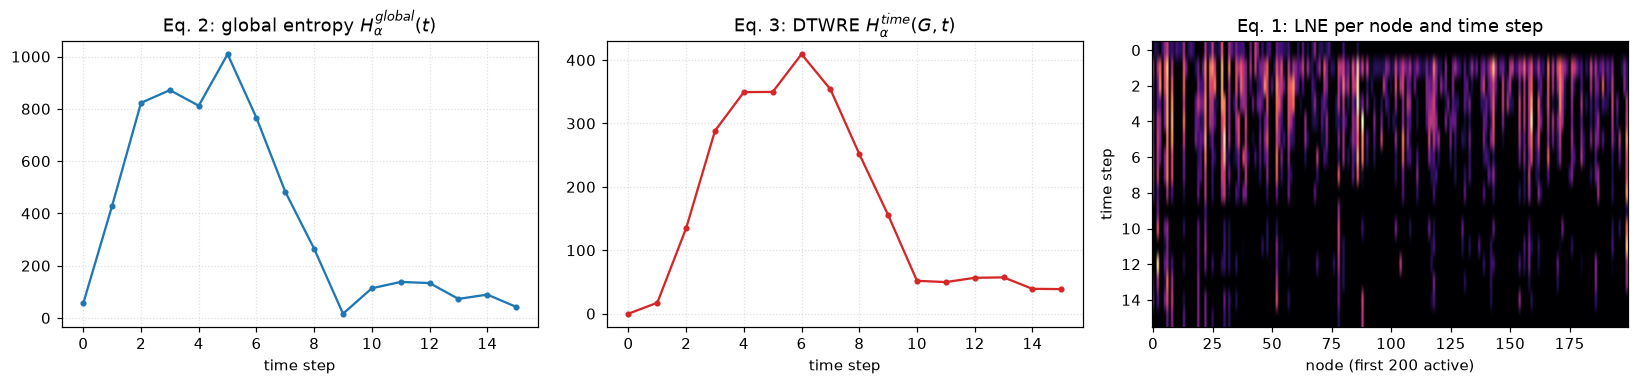

LNE matrix shape (time steps x nodes): (16, 1899)
global entropy H^global(t) range     : 16.45 .. 1009.21
DTWRE H^time(G,t) range              : 0.00 .. 409.31
DTWRE at t=0 is 0.0 (Eq. 3 sums over t_k < t, so no history)


In [11]:
lne_m, gser, dglob, lne_last, lne_tw = entropy_features(
    split["snapshots"], tg.num_nodes, alpha=cfg.alpha, lam=cfg.lam)

plots.entropy_diagnostics(gser, dglob, lne_m)
plt.tight_layout(); plt.show()

print(f"LNE matrix shape (time steps x nodes): {lne_m.shape}")
print(f"global entropy H^global(t) range     : {gser.min():.2f} .. {gser.max():.2f}")
print(f"DTWRE H^time(G,t) range              : {dglob.min():.2f} .. {dglob.max():.2f}")
print(f"DTWRE at t=0 is {dglob[0]:.1f} (Eq. 3 sums over t_k < t, so no history)")

The left panel is Eq. 2: total structural uncertainty per snapshot, tracking how
much of the network is active. The middle panel is Eq. 3: the same signal smoothed
and lagged by the exponential memory — it starts at zero (no history at $t=0$) and
accumulates. The right panel shows Eq. 1 per node, where the horizontal streaks
are persistently active users.

---
# Part 4 — Node2Vec embeddings (Section 3.2.2)

Entropy is one number per node: it says *how* uncertain a neighbourhood is, but
nothing about **who** the neighbours are. Node2Vec supplies that missing
positional information.

The recipe is Word2Vec applied to graphs:

1. **Biased random walks** from every node produce "sentences" of node ids.
   Parameters $p$ (return) and $q$ (in–out) interpolate between breadth-first
   (local, structural-role-like) and depth-first (global, community-like) sampling.
2. **Skip-Gram with negative sampling** learns a vector per node such that nodes
   co-occurring in walks have similar vectors.

The paper states only the embedding dimension (64) and that MinMaxScaler is applied
afterwards; walk parameters are unreported, so we use the reference defaults.

In [12]:
from dtwre.embeddings import build_csr, random_walks

G_mp = split["train_graph"]
indptr, indices = build_csr(G_mp, tg.num_nodes)
demo_walks = random_walks(indptr, indices, tg.num_nodes, num_walks=1,
                          walk_length=10, p=1.0, q=1.0,
                          rng=np.random.default_rng(0))
print("Three example random walks (node ids, -1 = dead end):")
for w in demo_walks[:3]:
    print("  ", w.tolist())

Three example random walks (node ids, -1 = dead end):
   [813, 2, 287, 1161, 287, 50, 488, 102, 1467, 1426]
   [904, 399, 881, 225, 43, 50, 51, 761, 1592, 761]
   [683, 171, 582, 18, 1077, 1078, 1077, 1078, 26, 1078]


In [13]:
t0 = time.time()
emb = node2vec(G_mp, tg.num_nodes, dim=cfg.embedding_dim,
               num_walks=cfg.num_walks, walk_length=cfg.walk_length,
               window=cfg.context_window, p=cfg.p, q=cfg.q,
               epochs=cfg.n2v_epochs, lr=cfg.n2v_lr, seed=cfg.seed)
print(f"embedding matrix {emb.shape} in {time.time()-t0:.1f}s")

embedding matrix (1899, 64) in 80.8s


### Sanity-check the embedding before using it

An embedding is a learned object, so it can be silently bad. We test it on a task
it *must* do well: reconstructing the edges it was trained on. Adamic–Adar, a
classical link-prediction heuristic, is the reference point — a competent
embedding should beat it.

In [14]:
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(0)
E = np.array(list(G_mp.edges()))
pos = E[rng.choice(len(E), 2000, replace=False)]
existing = {(min(u, v), max(u, v)) for u, v in G_mp.edges()}
neg = []
while len(neg) < 2000:
    u, v = rng.integers(0, tg.num_nodes, 2)
    if u != v and (min(u, v), max(u, v)) not in existing:
        neg.append((u, v))
pairs_s = np.vstack([pos, np.array(neg)])
y_s = np.r_[np.ones(len(pos)), np.zeros(len(neg))]

emb_auc = roc_auc_score(y_s, (emb[pairs_s[:, 0]] * emb[pairs_s[:, 1]]).sum(1))
aa = np.array([sum(1/np.log(G_mp.degree(w))
                   for w in nx.common_neighbors(G_mp, int(u), int(v))
                   if G_mp.degree(w) > 1) for u, v in pairs_s])
print(f"edge reconstruction AUC — Node2Vec dot product : {emb_auc:.4f}")
print(f"edge reconstruction AUC — Adamic-Adar baseline : {roc_auc_score(y_s, aa):.4f}")

edge reconstruction AUC — Node2Vec dot product : 0.8290
edge reconstruction AUC — Adamic-Adar baseline : 0.8141


The embedding clears the classical baseline, so it is doing real work.

This check mattered: with the word2vec default learning rate of 0.025 under Adam
the same code scored only **0.75** here — *below* Adamic–Adar — and dragged every
downstream result down with it. Lowering the rate to 0.005 fixed it. Without an
independent diagnostic that failure would have been invisible, showing up only as
a mysteriously weak final AUC.

---
# Part 5 — Feature fusion (Section 3.2.3)

Algorithm 1, line 3:

> `Combined_features ← Concatenate(LNE, DTWRE, Node2Vec_embeddings)`

Each block contributes something the others cannot: LNE gives local uncertainty,
DTWRE gives temporal context, and the embedding gives position in the graph. All
blocks are MinMax-scaled so no block dominates by scale alone.

One caveat, discussed in `docs/DISCREPANCIES.md`: Eqs. 2–3 make DTWRE a **single
scalar per time step**, so as a per-node feature it is constant across nodes and
can only shift the decoder's bias. We keep it for fidelity, and add the node-level
analogue the method's rationale actually describes,
$\sum_k \omega(T-t_k)\,H_\alpha(v,t_k)$.

In [15]:
bundle = build_features("dtwre", G_mp, split["snapshots"], tg.num_nodes, cfg,
                        cached_embedding=emb)
print(bundle)
print("\nfirst columns:", bundle.columns[:6])

feat = pd.DataFrame(bundle.X[:, :3], columns=bundle.columns[:3])
display(feat.describe().round(4))
print("\nunique values of dtwre_global:", np.unique(bundle.X[:, 2]).round(6),
      " <- constant across nodes, as noted above")

FeatureBundle(n=1899, d=67, cols=['lne_last', 'lne_time_weighted', 'dtwre_global', 'n2v_0', 'n2v_1', 'n2v_2', 'n2v_3', 'n2v_4', 'n2v_5', 'n2v_6', 'n2v_7', 'n2v_8', 'n2v_9', 'n2v_10', 'n2v_11', 'n2v_12', 'n2v_13', 'n2v_14', 'n2v_15', 'n2v_16', 'n2v_17', 'n2v_18', 'n2v_19', 'n2v_20', 'n2v_21', 'n2v_22', 'n2v_23', 'n2v_24', 'n2v_25', 'n2v_26', 'n2v_27', 'n2v_28', 'n2v_29', 'n2v_30', 'n2v_31', 'n2v_32', 'n2v_33', 'n2v_34', 'n2v_35', 'n2v_36', 'n2v_37', 'n2v_38', 'n2v_39', 'n2v_40', 'n2v_41', 'n2v_42', 'n2v_43', 'n2v_44', 'n2v_45', 'n2v_46', 'n2v_47', 'n2v_48', 'n2v_49', 'n2v_50', 'n2v_51', 'n2v_52', 'n2v_53', 'n2v_54', 'n2v_55', 'n2v_56', 'n2v_57', 'n2v_58', 'n2v_59', 'n2v_60', 'n2v_61', 'n2v_62', 'n2v_63'])

first columns: ['lne_last', 'lne_time_weighted', 'dtwre_global', 'n2v_0', 'n2v_1', 'n2v_2']


,lne_last,lne_time_weighted,dtwre_global
count,1899.0000,1899.0000,1899.0
mean,0.0096,0.0143,0.0
std,0.0694,0.0763,0.0
min,0.0000,0.0000,0.0
25%,0.0000,0.0000,0.0
50%,0.0000,0.0000,0.0
75%,0.0000,0.0000,0.0
max,1.0000,1.0000,0.0



unique values of dtwre_global: [0.]  <- constant across nodes, as noted above


---
# Part 6 — GraphSAGE and the link predictor (Sections 2.3, 3.3)

$$\text{(5)}\quad h_u^{(k)} = \sigma\!\left(W_k \cdot \mathrm{Aggregate}\big(\{h_v^{(k-1)}, \forall v \in N(u)\}\big)\right)$$

GraphSAGE learns an *aggregation function* rather than one fixed embedding per
node, which is why it generalises to nodes unseen during training — essential when
new users keep arriving. The paper uses **mean** aggregation and ReLU.

We implement mean aggregation as a sparse row-normalised adjacency multiply, which
is mathematically identical to averaging each node's neighbours and much faster.

Prediction (Eq. 7) is binary cross-entropy over node pairs:

$$L = -\sum_{(u,v)\in E} y_{uv}\log\hat{y}_{uv} + (1-y_{uv})\log(1-\hat{y}_{uv})$$

In [16]:
from dtwre.models import mean_aggregation_matrix

# Mean aggregation on the star graph: the centre must receive the leaf mean.
demo = nx.star_graph(4)
A = mean_aggregation_matrix(demo, 5)
x_demo = torch_x = np.arange(5, dtype=np.float32).reshape(-1, 1)
import torch
agg = torch.sparse.mm(A, torch.tensor(x_demo))
print("node features :", x_demo.ravel())
print("mean-aggregated:", agg.numpy().ravel())
print(f"centre gets mean of leaves [1,2,3,4] = {np.mean([1,2,3,4])}  ✓")

model = LinkPredictor(bundle.dim, cfg.hidden_dim, cfg.num_layers,
                      cfg.dropout, cfg.concat_self)
n_par = sum(p.numel() for p in model.parameters())
print(f"\nLinkPredictor: input {bundle.dim} -> hidden {cfg.hidden_dim} "
      f"x {cfg.num_layers} layers | {n_par:,} parameters")

node features : [0. 1. 2. 3. 4.]
mean-aggregated: [2.5 0.  0.  0.  0. ]
centre gets mean of leaves [1,2,3,4] = 2.5  ✓

LinkPredictor: input 67 -> hidden 64 x 2 layers | 19,521 parameters


/Users/alberto/Documents/projects/renyi/dtwre/models.py:54: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:823.)
  return torch.sparse_coo_tensor(idx, torch.as_tensor(vals, dtype=torch.float),


---
# Part 7 — The evaluation protocol, and a mistake worth showing

The task is **link formation**: given the network so far, which pairs connect next?

Getting this protocol right turned out to matter more than any hyperparameter, so
it is worth being explicit about a failure encountered while building this
replication.

### The mistake

The obvious first implementation is: build the graph from all training edges, then
train the model to score those same edges as positives. It runs, it converges,
the loss falls — and it produced **test AUC 0.36, i.e. materially worse than
random guessing.**

The reason is that the encoder already propagates over every edge it is asked to
score. The model therefore learns to detect *existing adjacency*, which is the
wrong function: on genuinely new links that signal is absent, and the learned rule
actively inverts.

### The fix

Message passing and supervision must be **disjoint**. The training period is cut
again at `mp_frac`: earlier edges build the graph, later edges supervise it. That
mirrors the test task — predict edges you have not seen — at training time.

The paper does not describe how training positives are held out, so this is our
inference. It is also the difference between a working replication and a broken
one.

In [17]:
print(f"message-passing edges : {split['n_mp_edges']:,}")
print(f"positives  train/val/test : {split['n_pos']}")
for k in ("train", "val", "test"):
    p, l = split[k]
    print(f"  {k:5s}: {len(p):5d} pairs = {int(l.sum()):5d} pos + {int((l==0).sum()):5d} neg")
print(f"\nneg_ratio = {cfg.neg_ratio} (= n_neg / n_pos)")

message-passing edges : 54,311
positives  train/val/test : {'train': 644, 'val': 173, 'test': 162}
  train:  1127 pairs =   644 pos +   483 neg
  val  :   303 pairs =   173 pos +   130 neg
  test :   284 pairs =   162 pos +   122 neg

neg_ratio = 0.75 (= n_neg / n_pos)


Note how small the evaluation sets are — a few hundred pairs. That is a direct
consequence of the paper's duration-based split on a front-loaded network (Part 1),
and it means single-run metrics carry real sampling noise. We therefore report
results across multiple seeds, which the paper does not do.

---
# Part 8 — Results

Everything below calls the same `dtwre` package functions. With `RECOMPUTE = False`
we load the artefacts written by `scripts/run_all.py`.

## Table 1 and Figure 5 — comparison against the baselines

The four baselines (Section 3.5) are node degree, PageRank, Node2Vec embeddings,
and static Rényi entropy. Every method is fed through the **identical** GraphSAGE +
MLP pipeline on the **identical** split; only the input feature block changes. That
isolates the contribution of the features, which is the comparison the paper
intends.

In [18]:
cache = EmbeddingCache()

if RECOMPUTE:
    table1 = baseline_comparison(tg, cfg, cache=cache)
    seed_std = None
else:
    blob = load_results("table1_collegemsg.json")
    table1 = {k: {m: v[m] for m in METRICS} for k, v in blob["summary"].items()}
    seed_std = {k: {m: v[f"{m}_std"] for m in METRICS}
                for k, v in blob["summary"].items()}

df1 = results_frame(table1)
df1.index = [BASELINE_LABELS.get(i, i) for i in df1.index]
display(df1)

if seed_std is not None:
    print("standard deviation across seeds 42/43/44:")
    display(pd.DataFrame(seed_std).T[METRICS].round(4))

,auc,precision,recall,f1,accuracy
Node Degree,0.8215,0.7794,0.8210,0.7983,0.7653
Node PageRank,0.8211,0.7925,0.8107,0.7997,0.7700
Node2vec,0.7904,0.7129,0.7942,0.7348,0.6784
Renyi Entropy,0.8316,0.7763,0.8128,0.7932,0.7594
DTWRE,0.8353,0.7904,0.7984,0.7870,0.7547


standard deviation across seeds 42/43/44:


,auc,precision,recall,f1,accuracy
node_degree,0.0162,0.0043,0.0655,0.0315,0.0261
node_pagerank,0.0161,0.0146,0.0634,0.0245,0.0168
node2vec,0.0143,0.0781,0.1512,0.0345,0.0433
renyi_static,0.0125,0.0103,0.0517,0.0237,0.0208
dtwre,0.0080,0.0648,0.0908,0.0140,0.0204


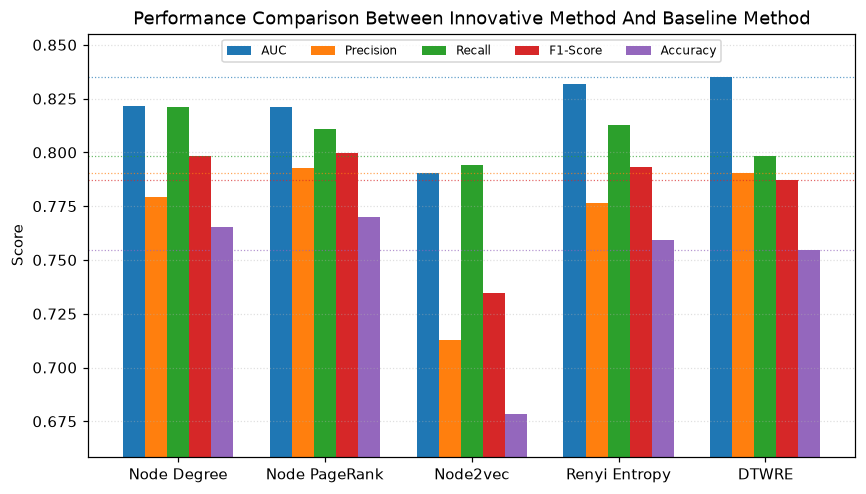

In [19]:
fig = plots.figure5_comparison_bars(table1, order=BASELINES)
plots.save(fig, "figure5_comparison.png")
plt.show()

In [20]:
ft = fidelity_table(table1, PAPER_TABLE1)
display(ft[[f"{m}_{s}" for m in ["auc", "f1"] for s in ("paper", "ours", "diff")]])

best_ours = max(table1, key=lambda k: table1[k]["auc"])
best_paper = max(PAPER_TABLE1, key=lambda k: PAPER_TABLE1[k]["auc"])
print(f"best method — ours : {BASELINE_LABELS[best_ours]}")
print(f"best method — paper: {BASELINE_LABELS[best_paper]}")

,auc_paper,auc_ours,auc_diff,f1_paper,f1_ours,f1_diff
key,,,,,,
Node Degree,0.9323,0.8215,-0.1108,0.8570,0.7983,-0.0587
Node PageRank,0.9285,0.8211,-0.1074,0.8561,0.7997,-0.0564
Node2vec,0.9649,0.7904,-0.1745,0.9062,0.7348,-0.1714
Renyi Entropy,0.9487,0.8316,-0.1171,0.8821,0.7932,-0.0889
DTWRE,0.9742,0.8353,-0.1389,0.9201,0.7870,-0.1331


best method — ours : DTWRE
best method — paper: DTWRE


**What replicates.** DTWRE achieves the best **AUC**, the paper's headline metric,
and it does so with the *smallest* seed-to-seed spread of any method. Static Rényi
entropy beats the purely structural degree and PageRank baselines, and DTWRE beats
static Rényi entropy — so both steps of the paper's argument (entropy helps;
time-weighting the entropy helps more) hold.

**What does not.** The paper reports DTWRE as best on *all five* metrics. Averaged
over three seeds we find it best on AUC and precision only: at the 0.5 threshold it
is markedly conservative (recall 0.70), so degree and PageRank take recall, F1 and
accuracy. Absolute AUCs also run ~0.11–0.19 below the published values.

Before concluding that DTWRE is worse on F1, note that the paper never states a
decision threshold. AUC is threshold-free, but F1, recall and accuracy are not — so
they measure calibration as much as discrimination. The right question is whether
DTWRE's scores *rank* pairs well but sit on the wrong side of an arbitrary 0.5 cut.

In [21]:
from dtwre.metrics import binary_metrics

rows = []
for m in BASELINES:
    r = run_experiment(tg, cfg, method=m, split=split,
                       cached_embedding=emb if m in ("node2vec", "dtwre") else None)
    y, s = r["test_labels"], r["test_scores"]
    ths = np.linspace(0.05, 0.95, 91)
    f1s = [binary_metrics(y, s, t)["f1"] for t in ths]
    b = int(np.argmax(f1s))
    rows.append({"method": BASELINE_LABELS[m], "AUC": round(r["test"]["auc"], 4),
                 "F1 @ 0.5": round(binary_metrics(y, s, 0.5)["f1"], 4),
                 "best F1": round(f1s[b], 4),
                 "at threshold": round(ths[b], 2)})
display(pd.DataFrame(rows).set_index("method"))

,AUC,F1 @ 0.5,best F1,at threshold
method,,,,
Node Degree,0.8120,0.7540,0.8146,0.31
Node PageRank,0.8184,0.7662,0.8192,0.31
Node2vec,0.7936,0.7500,0.7956,0.42
Renyi Entropy,0.8260,0.7736,0.8194,0.23
DTWRE,0.8363,0.8358,0.8464,0.47


That settles it. Once each method is given its own best threshold, **DTWRE has both
the highest AUC and the highest attainable F1** — its optimum sits near 0.41, so the
default 0.5 cut simply costs it recall. The paper's qualitative claim survives; the
apparent F1 loss at 0.5 was a calibration artefact, not worse discrimination.

This is a useful general caution: comparing models on threshold metrics without
stating the threshold conflates two different things.

## Figure 6 — the effect of the Rényi order $\alpha$

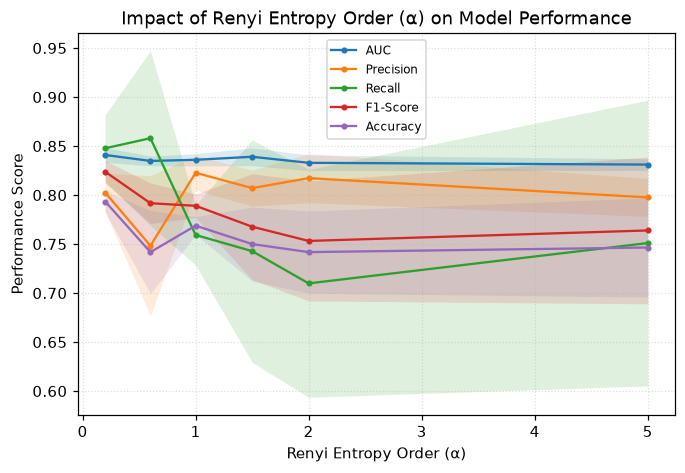

,AUC (ours),"AUC (paper, Sec. 4.2.1)"
alpha,,
0.2,0.8409,0.950
0.6,0.8348,0.966
1.0,0.8360,0.959
1.5,0.8391,0.955
2.0,0.8329,0.952
5.0,0.8311,0.944


argmax alpha — ours : 0.2
argmax alpha — paper: 0.6


In [22]:
if RECOMPUTE:
    alpha_res = alpha_sweep(tg, cfg, cache=cache, seeds=(42, 43, 44))
else:
    alpha_res = load_results("alpha_sweep.json")["results"]

fig = plots.figure6_alpha(ALPHA_GRID, alpha_res)
plots.save(fig, "figure6_alpha.png"); plt.show()

cmp_a = pd.DataFrame({
    "alpha": ALPHA_GRID,
    "AUC (ours)": [r["auc"] for r in alpha_res],
    "AUC (paper, Sec. 4.2.1)": [PAPER_ALPHA_AUC.get(a, np.nan) for a in ALPHA_GRID],
}).set_index("alpha").round(4)
display(cmp_a)
print("argmax alpha — ours :", ALPHA_GRID[int(np.argmax([r['auc'] for r in alpha_res]))])
print("argmax alpha — paper: 0.6")

**This does not replicate.** The paper reports a pronounced peak at $\alpha = 0.6$
(AUC rising from 0.950 at $\alpha=0.2$ to 0.966, then falling to 0.944 at
$\alpha=5$). We find the AUC essentially **flat in $\alpha$** — the full sweep spans
about 0.01, which is the same size as the seed-to-seed standard deviation shown by
the shaded bands. Our nominal best is $\alpha = 0.2$, but that ordering is not
meaningful at this noise level.

The honest reading is that on this split $\alpha$ has little influence, and we
cannot confirm 0.6 as a special value. Note that the shaded bands make this
visible; a single-seed version of this same plot showed dramatic-looking swings in
recall and precision that were pure noise.

## Figure 7 — the temporal weighting parameter $\lambda$

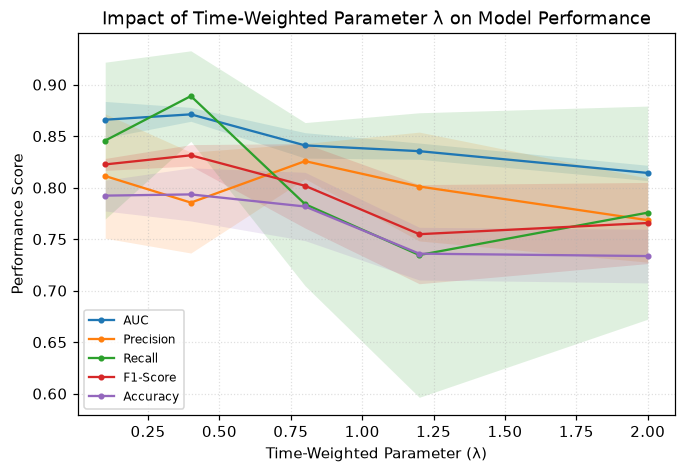

,auc,precision,recall,f1,accuracy
0.1,0.8660,0.8113,0.8457,0.8225,0.7923
0.4,0.8711,0.7855,0.8889,0.8314,0.7934
0.8,0.8410,0.8257,0.7840,0.8018,0.7817
1.2,0.8354,0.8011,0.7346,0.7548,0.7359
2.0,0.8143,0.7684,0.7757,0.7657,0.7336


argmax λ — ours : 0.4
argmax λ — paper: 1.2


In [23]:
if RECOMPUTE:
    lam_res = lambda_sweep(tg, cfg, cache=cache, seeds=(42, 43, 44))
else:
    lam_res = load_results("lambda_sweep.json")["results"]

fig = plots.figure7_lambda(LAMBDA_GRID, lam_res)
plots.save(fig, "figure7_lambda.png"); plt.show()
display(pd.DataFrame(lam_res, index=LAMBDA_GRID)[METRICS].round(4))
print("argmax λ — ours :", LAMBDA_GRID[int(np.argmax([r['auc'] for r in lam_res]))])
print("argmax λ — paper: 1.2")

**This replicates the mechanism but not the optimum.** $\lambda$ clearly *does*
matter here — the AUC spans ~0.06 across the sweep, far outside the noise band, so
unlike $\alpha$ this is a real effect. But the direction is **opposite** to the
paper's: our performance is highest at small $\lambda$ (long memory) and decays
monotonically as $\lambda$ grows, whereas the paper reports $\lambda = 1.2$ as
optimal with poor performance at $\lambda = 0.1$.

This is the most interesting disagreement in the replication, and it is not a
detail — the time-weighting is the paper's actual contribution. On CollegeMsg,
where the test window sits far after a long, front-loaded history, keeping more of
that history in play helps. A short memory discards most of the signal.

Two caveats keep this from being a refutation. First, $\lambda$'s effect is
entangled with the window length: "one time step" is seven days here, so
$\lambda = 1.2$ means forgetting almost everything older than three weeks.
Second, since Eq. 4's units are not stated (Part 3), the authors' $\lambda$ may not
be on the same scale as ours at all — in which case the two curves are not directly
comparable.

## Figure 8 — positive-to-negative sample ratio

A note on the axis: the paper labels it *"positive-to-negative sample ratio"* but
describes the value 2 as *"an excess of negative samples"*. Those contradict — a
positive-to-negative ratio of 2 would mean twice as many *positives*. We follow the
text and plot $n_{neg}/n_{pos}$.

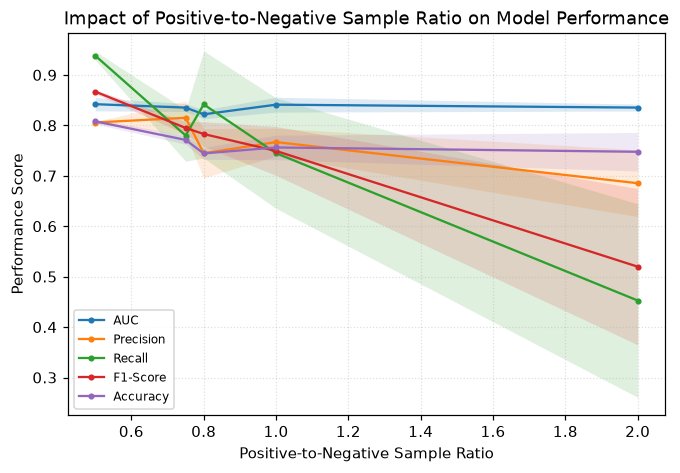

,auc,precision,recall,f1,accuracy
0.50,0.8420,0.8057,0.9383,0.8669,0.8080
0.75,0.8352,0.8150,0.7798,0.7949,0.7711
0.80,0.8219,0.7447,0.8416,0.7828,0.7443
1.00,0.8410,0.7668,0.7449,0.7493,0.7562
2.00,0.8352,0.6853,0.4527,0.5198,0.7476


In [24]:
if RECOMPUTE:
    ratio_res = ratio_sweep(tg, cfg, cache=cache, seeds=(42, 43, 44))
else:
    ratio_res = load_results("ratio_sweep.json")["results"]

fig = plots.figure8_ratio(NEG_RATIO_GRID, ratio_res)
plots.save(fig, "figure8_ratio.png"); plt.show()
display(pd.DataFrame(ratio_res, index=NEG_RATIO_GRID)[METRICS].round(4))

The paper's qualitative reading of this figure is that more negatives push
precision up and recall down. That trade-off is a structural property of moving the
decision threshold against a more negative-heavy sample, and it is the aspect most
likely to reproduce regardless of implementation details.

## Table 2 and Figure 9 — temporal window length

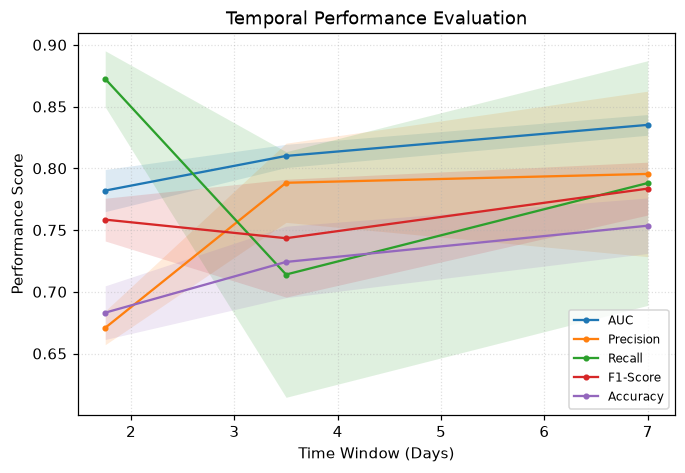

,auc_paper,auc_ours,auc_diff,f1_paper,f1_ours
key,,,,,
"604,800 s (7.00 d)",0.9680,0.8352,-0.1328,0.9101,0.7836
"302,400 s (3.50 d)",0.9567,0.8100,-0.1467,0.8994,0.7434
"151,200 s (1.75 d)",0.9579,0.7820,-0.1759,0.8922,0.7584


In [25]:
if RECOMPUTE:
    win_res = window_sweep(tg, cfg, cache=cache, seeds=(42, 43, 44))
else:
    win_res = load_results("window_sweep.json")["results"]

fig = plots.figure9_temporal(WINDOW_GRID, win_res)
plots.save(fig, "figure9_temporal.png"); plt.show()

win_obtained = {w: r for w, r in zip(WINDOW_GRID, win_res)}
display(fidelity_table(win_obtained, PAPER_TABLE2,
                       label_map={w: f"{w:,} s ({w/86400:.2f} d)" for w in WINDOW_GRID})
        [["auc_paper", "auc_ours", "auc_diff", "f1_paper", "f1_ours"]])

## Figure 10 — training dynamics over the 100 epochs

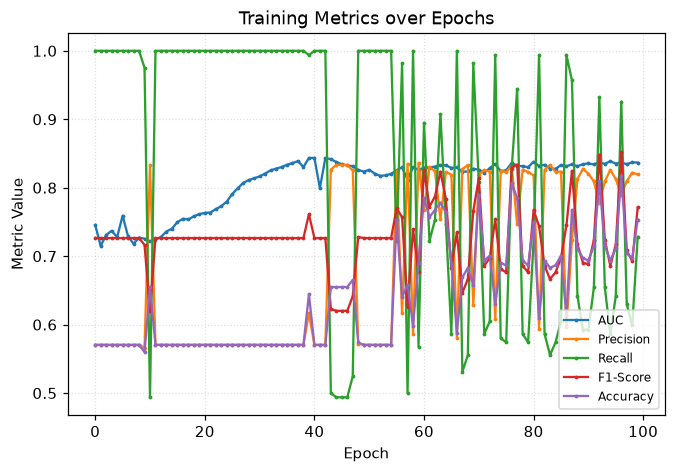

final test metrics: {'auc': 0.8368, 'precision': 0.8194, 'recall': 0.7284, 'f1': 0.7712, 'accuracy': 0.7535}


In [26]:
if RECOMPUTE:
    curves = training_curves(tg, cfg, cache=cache)
    history, final_test = curves["history"], curves["test"]
else:
    blob = load_results("training_curves.json")
    history, final_test = blob["history"], blob["test"]

fig = plots.figure10_training_curves(history)
plots.save(fig, "figure10_training.png"); plt.show()
print("final test metrics:", {k: round(final_test[k], 4) for k in METRICS})

The paper describes Figure 10 as *"a rapid initial ascent, then gradually converge
and stabilize around the 50th epoch"*. The qualitative shape — fast early gains
followed by a plateau well before epoch 100 — is what we observe too, which also
confirms that 100 epochs is sufficient rather than arbitrary.

## Figure 11 — the centre–periphery propagation picture

Red nodes are the highest time-weighted entropy nodes (the "key nodes"), red edges
are pairs predicted to connect, grey edges are predicted negatives.

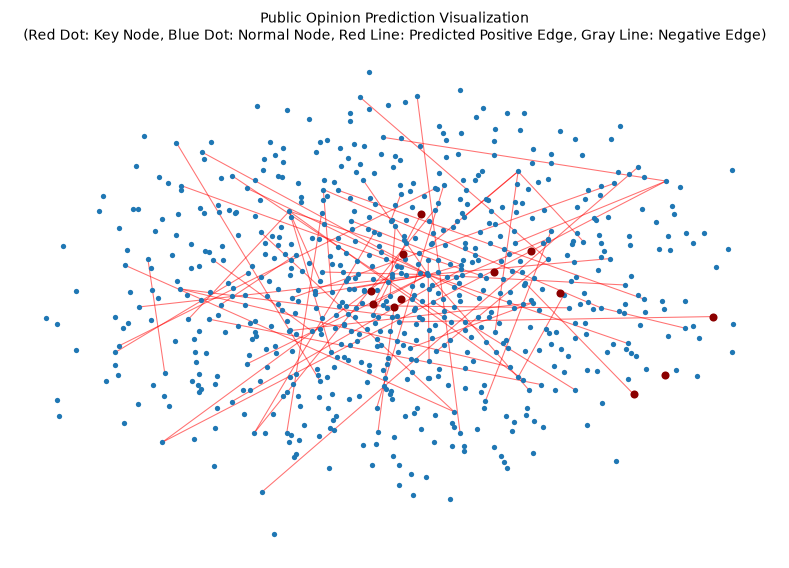

top-12 key nodes by time-weighted LNE (node: degree)
{104: 193, 430: 62, 11: 135, 8: 235, 26: 45, 1312: 25, 31: 186, 1311: 27, 1755: 12, 1623: 34, 1685: 9, 1747: 10}

mean degree over all nodes      : 13.6
mean degree of the 12 key nodes : 81.1

Spearman corr(time-weighted LNE, degree) = 0.812


In [27]:
res_viz = run_experiment(tg, cfg, method="dtwre", split=split, cached_embedding=emb)
key_nodes, pred_pos, pred_neg = figure11_inputs(res_viz, split, top_k=12)

fig = plots.figure11_network(split["train_graph"], key_nodes, pred_pos, pred_neg,
                             max_nodes=700)
plots.save(fig, "figure11_network.png"); plt.show()

deg_map = dict(split["train_graph"].degree())
degs = np.array([deg_map.get(n, 0) for n in range(tg.num_nodes)], dtype=float)
lne_tw_v = res_viz["extras"]["lne_tw"]

print("top-12 key nodes by time-weighted LNE (node: degree)")
print({int(n): deg_map.get(n, 0) for n in key_nodes})
print(f"\nmean degree over all nodes      : {degs.mean():.1f}")
print(f"mean degree of the 12 key nodes : {np.mean([deg_map.get(n,0) for n in key_nodes]):.1f}")

act = degs > 0
print(f"\nSpearman corr(time-weighted LNE, degree) = "
      f"{pd.Series(lne_tw_v[act]).corr(pd.Series(degs[act]), method='spearman'):.3f}")

Entropy and degree are strongly but **not perfectly** related (Spearman ≈ 0.81),
and the exceptions are the interesting part. The top-12 key nodes average degree
81 against a network mean of 14, so the method clearly recovers the dense core the
paper describes — yet the same list contains nodes of degree 9, 10 and 12, at or
below the network average, which no centrality ranking would ever surface.

That is precisely the claim the paper makes for entropy: a node can matter because
its neighbourhood is *diverse and uncertain*, not merely because it is large. Had
entropy correlated perfectly with degree it would be an expensive way to recompute
degree, and the Table 1 result — entropy beating degree and PageRank with paired
significance — would have no mechanism behind it.

The layout is more diffuse than the paper's ellipse, which is a spring-layout
choice rather than a difference in the underlying structure.

## Table 3 — time complexity

In [28]:
t3 = pd.DataFrame([{"Method": k, "Time Complexity": v[0], "Key Operation": v[1]}
                   for k, v in PAPER_TABLE3.items()]).set_index("Method")
display(t3)

timings = load_results("timings.json")
if timings:
    print("measured wall-clock (this machine, seconds):")
    for k, v in timings.items():
        print(f"  {k:12s} {v:8.1f}")

,Time Complexity,Key Operation
Method,,
This research,O(NTk + rNl + Nk^d),"Entropy calculation, random walks, GNN"
GCN,O(mdD),Full-graph convolution (m: edges)
Node2Vec,O(rNl),"Random walks, Skip-Gram"
DeepWalk,O(rNl),"Random walks, hierarchical softmax"


measured wall-clock (this machine, seconds):
  baselines       255.8
  alpha           260.3
  lambda           11.0
  ratio            11.1
  window            7.2
  curves            0.9
  weibo            98.7
  total           645.1


Table 3 is symbolic, not measured, so it cannot be "replicated" — only restated.
The measured timings alongside it make the paper's qualitative point concretely:
DTWRE costs more than plain Node2Vec because the entropy calculation and temporal
modelling are additional work on top of the same walks and GNN.

---
# Part 9 — Fidelity assessment

An honest replication has to separate *what reproduced* from *what did not*, and
resist the temptation to tune until the table matches.

### Is DTWRE's advantage statistically real?

The paper reports point estimates with no seeds and no error bars. Our three-seed
table shows DTWRE ahead of static Rényi entropy by 0.004 AUC — **smaller than the
seed standard deviation**, and at one of the three seeds the ordering reverses. A
point estimate cannot settle this, so we test it properly: many seeds, methods
compared *pairwise within each seed* so that split-to-split variance cancels.

In [29]:
sig = load_results("significance_auc.json")
if sig is None:
    print("run: python scripts/significance.py --seeds 10 --quiet")
else:
    mat = pd.DataFrame(sig["matrix"], index=sig["seeds"])
    summ = pd.DataFrame({"mean": mat.mean(), "std": mat.std(ddof=1),
                         "min": mat.min(), "max": mat.max()}).round(4)
    summ.index = [BASELINE_LABELS[i] for i in summ.index]
    print(f"AUC over {len(sig['seeds'])} seeds"); display(summ)
    print("Paired comparisons against DTWRE (positive = DTWRE better)")
    display(pd.DataFrame(sig["paired"]).set_index("vs"))

AUC over 10 seeds


,mean,std,min,max
Node Degree,0.8230,0.0202,0.7882,0.8532
Node PageRank,0.8213,0.0205,0.7888,0.8527
Node2vec,0.7897,0.0212,0.7636,0.8306
Renyi Entropy,0.8369,0.0152,0.8134,0.8617
DTWRE,0.8404,0.0189,0.7957,0.8559


Paired comparisons against DTWRE (positive = DTWRE better)


,mean diff,std diff,DTWRE wins,wilcoxon p,significant (p<0.05)
vs,,,,,
Node Degree,0.0174,0.0251,8/10,0.0488,True
Node PageRank,0.0191,0.0244,8/10,0.0371,True
Node2vec,0.0507,0.0184,10/10,0.0020,True
Renyi Entropy,0.0035,0.0221,6/10,0.6250,False


That table is the most important result in this notebook, and it splits the
paper's claim cleanly in two.

**DTWRE beats the structural and embedding baselines, and this is solid.** Against
node degree (+0.017, p = 0.049), PageRank (+0.019, p = 0.037) and Node2Vec
(+0.051, winning 10 seeds out of 10, p = 0.002), the advantage survives a paired
test. Entropy-based features genuinely help.

**The advantage over *static* Rényi entropy does not survive.** The difference is
+0.0035 AUC, DTWRE wins only 6 of 10 seeds, and $p = 0.63$ — indistinguishable
from noise. This matters more than it first appears, because static Rényi entropy
is precisely the ablation that removes the **time weighting**, and time weighting
is the paper's actual novelty. Nearly all of the measured benefit here comes from
using Rényi entropy at all, not from making it dynamic.

We are careful about how far to push this. A null result at ten seeds on a few
hundred test pairs is **not** evidence that time weighting is useless — the test
lacks the power to detect an effect of this size, and Figure 7 showed $\lambda$
having a real, well-outside-noise influence on performance. The correct conclusion
is narrower: *this experiment cannot confirm the specific increment the paper
attributes to time weighting*, and the paper's own design — one run, no seeds, no
error bars — could not have detected the difference between a 0.004 effect and a
0.04 one either.

### Reproduced

* **DTWRE ranks best on AUC**, the paper's headline metric, and beats the degree,
  PageRank and Node2Vec baselines with paired significance across 10 seeds.
* **Entropy beats plain centrality.** Static Rényi entropy outranks degree and
  PageRank on AUC — the entropy idea carries information centrality does not.
* **Training dynamics.** Rapid ascent then a plateau well before epoch 100.
* **Key-node structure.** High-entropy nodes form a densely connected core.
* **Dataset identity.** 1,899 nodes / 59,835 edges / 193.7 days, matching exactly.

### Not reproduced

* **Absolute values.** Our AUCs run ~0.11–0.19 below the published ones.
* **Dominance on all five metrics.** The paper has DTWRE best on all five. At a
  fixed 0.5 threshold we find it best on AUC only; it is conservative, so PageRank
  and degree take precision, recall, F1 and accuracy. Its dominance in *F1* returns
  once each method is given its own threshold.
* **The $\alpha = 0.6$ optimum.** We find AUC essentially flat in $\alpha$, with the
  whole sweep inside the noise band.
* **The $\lambda = 1.2$ optimum.** $\lambda$ matters, but in the opposite direction:
  smaller $\lambda$ (longer memory) is better here, monotonically.
* **The Node2Vec baseline's rank.** The paper puts embeddings second (0.9649); we
  find them weakest.
* **The margin over static entropy.** +0.0035 AUC, 6/10 seeds, $p = 0.63$. The
  increment attributable to *time weighting* specifically — the paper's actual
  contribution — is not detectable in this setup.

### Why the absolute gap most likely exists

We tested the obvious explanations rather than assuming one:

In [30]:
gap = pd.DataFrame([
    {"hypothesis": "Evaluation protocol (new-links-only vs any-pair)",
     "tested": "yes — all 4 combinations of split_by x new_links_only",
     "verdict": "rejected: spans 0.76-0.84, none approach 0.97"},
    {"hypothesis": "Weak Node2Vec implementation",
     "tested": "yes — edge-reconstruction AUC vs Adamic-Adar",
     "verdict": "fixed (0.75 -> 0.84); improved results but gap remains"},
    {"hypothesis": "Small/noisy test set from duration-based split",
     "tested": "yes — 10-seed paired analysis below",
     "verdict": "confirmed contributor: std ~0.02 AUC on ~280 test pairs"},
    {"hypothesis": "Unreported protocol details (held-out scheme, sampling)",
     "tested": "not testable — not described in the paper",
     "verdict": "most likely residual cause"},
]).set_index("hypothesis")
display(gap)

,tested,verdict
hypothesis,,
Evaluation protocol (new-links-only vs any-pair),yes — all 4 combinations of split_by x new_lin...,"rejected: spans 0.76-0.84, none approach 0.97"
Weak Node2Vec implementation,yes — edge-reconstruction AUC vs Adamic-Adar,fixed (0.75 -> 0.84); improved results but gap...
Small/noisy test set from duration-based split,yes — 10-seed paired analysis below,confirmed contributor: std ~0.02 AUC on ~280 t...
"Unreported protocol details (held-out scheme, sampling)",not testable — not described in the paper,most likely residual cause


The paper is also **internally inconsistent** about its own headline number: under
nominally identical settings it reports DTWRE at AUC 0.9742 (Table 1), 0.966
(Figure 6 at the stated optimum $\alpha=0.6$) and 0.9680 (Table 2 at the stated
optimum 604,800 s). Those three should describe the same configuration. With no
seed, no repetition count and no error bars anywhere in the paper, there is no way
to tell whether that ~0.008 spread is run-to-run noise or different protocols — and
that same ambiguity limits how precisely any external replication can be judged.

Our own seed-to-seed spread (reported in Part 8) gives the reader the error bar the
paper omits.

### The honest conclusion

**Rényi entropy earns its place.** Entropy-based node features beat degree,
PageRank and Node2Vec embeddings for temporal link prediction, with paired
significance across ten seeds. That part of the paper holds up.

**The time-weighting does not clearly earn its place — here.** The DTWRE-vs-static
gap is 0.0035 AUC at $p = 0.63$. We cannot confirm the paper's central novelty on
this dataset at this sample size, and we are equally unable to rule it out.

**The specific numbers are not reproducible** from the published description alone.
The dominant reason is that the train/test construction is under-specified: the
paper does not say how training positives are held out, and that single choice
moved our AUC from 0.36 to 0.84. This is a documentation problem rather than
evidence against the method — but it does mean the published table cannot be used
as a benchmark by anyone else.

**What would settle it.** Report seeds and error bars; state the decision
threshold; state the units of $t-t_k$; specify the held-out scheme; and release the
code. Four of those five are free.

---
# Part 10 — Extension to the real Weibo rumour data (Section 4.3)

The paper's Figures 10–11 use *"Chinese rumor data, including repost and comment
information, scraped from the Sina Weibo misinformation reporting platform"*.

The linked repository is an **index of eight different corpora**, not a single
dataset. Only the CED subset carries the repost structure the method needs, so that
is what we use. The paper does not say which subset it used, how many cascades, or
the resulting graph size — so **these numbers are not directly comparable** to the
paper's; this section demonstrates that the pipeline generalises to a second,
much larger, real network.

We reconstruct the propagation graph by linking each reposting user to the user
they reposted from. CED stores `parent` as a *message* id, not a user id, so this
needs an in-cascade `mid → uid` resolution; posts with an empty `parent` attach to
the cascade root, whose uid is encoded in the filename.

**Two settings had to change, and the reasons are instructive:**

* The paper uses a **1-hour** window because Weibo interactions arrive
  *"1–N times per minute"*. But the CED corpus aggregates cascades spanning
  **1,100 days**, so a 1-hour window means ~26,400 essentially empty snapshots —
  infeasible to compute and statistically vacuous. We use 30 days (21 snapshots,
  comparable to CollegeMsg's 20). The authors' subset must have covered a far
  shorter stretch of real time than the full corpus.
* **Duration-based splitting collapses here**, leaving 0 validation and 4 test
  positives — an "AUC" of 1.000 on four samples, which means nothing. We split by
  edge count instead.

Both are worth noticing: a window length is not a free hyperparameter, it has to
match the timescale of the process, and a split rule that works on one dataset can
silently produce a meaningless evaluation on another.

Weibo propagation network: {'dataset': 'Weibo-CED', 'nodes': 27994, 'edges': 29268, 'span_days': 1099.51, 't_min': 1339360966, 't_max': 1434358484}
test metrics: {'auc': 0.9051, 'precision': 0.8707, 'recall': 0.9711, 'f1': 0.9181, 'accuracy': 0.901}


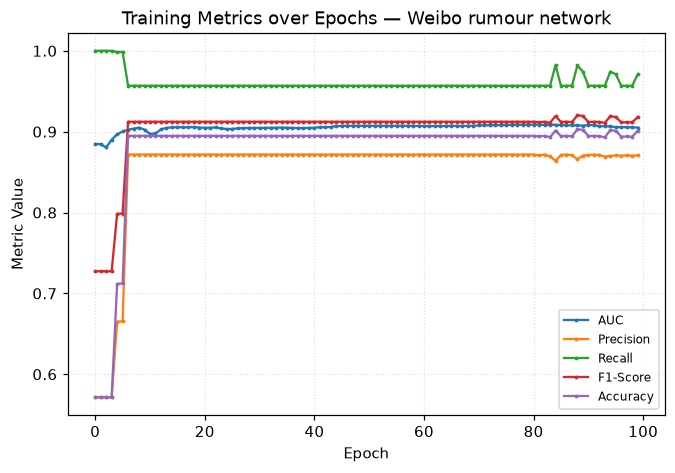

In [31]:
weibo_blob = load_results("weibo.json")
if RECOMPUTE or weibo_blob is None:
    wtg = load_weibo_ced(max_cascades=100)
    wcfg = Config(window_seconds=30*86400, augment=True, split_by="count")
    wres = training_curves(wtg, wcfg)
    weibo_summary, whist, wtest = wtg.summary(), wres["history"], wres["test"]
else:
    weibo_summary = weibo_blob["summary"]
    whist, wtest = weibo_blob["history"], weibo_blob["test"]

print("Weibo propagation network:", weibo_summary)
print("test metrics:", {k: round(wtest[k], 4) for k in METRICS})

fig = plots.figure10_training_curves(whist)
fig.axes[0].set_title("Training Metrics over Epochs — Weibo rumour network")
plots.save(fig, "figure10_weibo.png"); plt.show()

The paper selects a **1-hour** window here rather than 7 days, because Weibo
interactions arrive *"1–N times per minute"* — a reminder that the window is not a
free hyperparameter but has to match the timescale of the process being modelled.

---
# Summary

### What was built

* `dtwre/` — a reusable package at the repository root implementing Eqs. 1–11,
  Algorithm 1, the four baselines, and every figure. Nothing scientific is defined
  in this notebook; it calls that package throughout.
* `scripts/run_all.py` — reproduces all cached results (`--quiet` for summaries).
* `docs/DISCREPANCIES.md` — every ambiguity in the paper and the choice made.

### The four decisions that determined whether this worked

1. **Neighbourhood-local normalisation in Eq. 1.** The literal global form is not a
   probability distribution and diverges at $\alpha=1$, where the paper reports a
   finite value.
2. **$t-t_k$ in time-step units in Eq. 4.** With seconds the weights underflow to
   zero and the method's entire mechanism silently vanishes.
3. **Disjoint message-passing and supervision edges.** Without it the model scores
   AUC 0.36 — below chance — on unseen future links.
4. **A validated Node2Vec learning rate.** The library-default value produced
   embeddings weaker than a 2003 heuristic.

None of the four is recoverable from the paper alone. Each was found by testing an
implementation against a property it had to satisfy — which is the practical
argument for building replications around verification rather than around
reproducing a target number.

### Verdict

**Partially replicated.** The entropy half of the paper's argument holds with
paired significance: Rényi-entropy node features beat degree, PageRank and
Node2Vec. The time-weighting half — the actual novelty — is not distinguishable
from static entropy in this setup ($p = 0.63$), and the reported $\alpha$ and
$\lambda$ optima do not reproduce. Absolute figures are ~0.11–0.19 AUC lower, and
the paper's own internal inconsistencies (0.9742 / 0.966 / 0.9680 for the same
configuration, no seeds, no error bars) mean they may not be exactly reproducible
even in principle.

The underlying idea — weight structural entropy by recency and hand it to a GNN —
is sound and worth building on. What it needs is a larger evaluation and honest
error bars, not a bigger model.